# Learning Koopman / Lifted Dynamics for the Kepler System

Workflow:

1. Import dependencies and helper functions
2. Define neural network modules
3. Generate trajectory data from the Kepler system
4. Train the lifted Koopman model
5. Perform long-term prediction and visualize energy curves

Before running this notebook, please make sure that `functions.py` is available in the project directory. It should define or import `torch`, `nn`, `geotorch`, `odeint`, `timeit`, `k_energy`, `p_energy`, and `t_energy`.


## 1. Import dependencies

In [19]:
from functions_base import *

## 2. Define neural network modules

`K_Net` learns a linear evolution operator in the lifted space. Its weight matrix is constrained to be orthogonal using `geotorch.orthogonal`.

`lift_Net` maps the original 4-dimensional state into a higher-dimensional lifted representation, while `Decoder` maps the lifted representation back to the original state space.


In [2]:
class K_Net(torch.nn.Module):
    def __init__(self, n_input, n_output):
        super(K_Net, self).__init__()
        self.recurrent_kernel = nn.Linear(n_input, n_output, bias=False)
        geotorch.orthogonal(self.recurrent_kernel, "weight")
        self.reset_parameters()

    def reset_parameters(self):
        M = self.recurrent_kernel.parametrizations.weight[0]
        self.recurrent_kernel.weight = M.sample("uniform")

    def forward(self, data):
        return self.recurrent_kernel(data)

class lift_Net(torch.nn.Module):
    def __init__(self, n_input, n_hidden, n_output):
        super(lift_Net, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(n_input, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_output),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

        self.k = torch.tensor(2.5, requires_grad=True)
        self.v = torch.randn([4 + lift_d, q], requires_grad=True)

    def forward(self, data):
        out = self.net(data)
        return out


class Decoder(nn.Module):
    def __init__(self, n_hidden):
        super(Decoder, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(4 + lift_d, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 4),
        )

        for m in self.net.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, mean=0, std=0.1)
                nn.init.constant_(m.bias, val=0)

    def forward(self, y):
        return self.net(y)


## 3. Generate trajectory data from the Kepler system

The Kepler system state is $X=(x,y,a,b)$, where $(x,y)$ denotes the position and $(a,b)$ denotes the velocity. We first generate the clean trajectory `true_y` using an ODE solver. Gaussian observation noise is added later during training.


In [20]:
class kepler(nn.Module):
    dim = 4

    def forward(self, t, X):
        dx = torch.zeros_like(X)
        x, y, a, b = X[:, 0], X[:, 1], X[:, 2], X[:, 3]
        dx[:, 0] = a
        dx[:, 1] = b
        dist = (x**2 + y**2) ** 1.5
        dx[:, 2] = -x / dist
        dx[:, 3] = -y / dist
        return dx


n = 50
y0 = torch.tensor([[1.0, 0.0, 0.0, 0.9]])
t = torch.linspace(0, 5, n)
true_y = odeint(kepler(), y0, t, atol=1e-8, rtol=1e-8)[:, 0, :]

print(true_y.shape)


torch.Size([50, 4])


## 4. Data reconstruction and visualization utilities

`re_data` constructs adjacent-time training pairs. `pred_pendulum` and `visual` are kept as diagnostic and visualization utilities for the later analysis.


In [21]:
def re_data(y, lift_y):
    x = torch.cat((y, lift_y), dim=1)
    X1, X2 = x[:-1], x[1:]
    return X1, X2


def pred_pendulum(K, X, T, n):
    Y = np.zeros([n, len(K)])
    X = X.detach().numpy()
    T = T.detach().numpy()
    Y[0, :] = T[0, :]

    for i in range(n - 1):
        x = Y[i, :].reshape(-1, 1)
        Y[i + 1, :] = np.matmul(K, x).T[0]

    plt.figure(figsize=(10, 4))
    plt.subplot(121)
    plt.scatter(np.arange(len(k_energy(T))), k_energy(T), label='kinetic')
    plt.scatter(np.arange(len(p_energy(T))), p_energy(T), label='total')
    plt.scatter(np.arange(len(t_energy(T))), t_energy(T), label='potential')
    plt.title('true energy')
    plt.legend()

    plt.subplot(122)
    plt.scatter(np.arange(len(k_energy(Y))), k_energy(Y), label='kinetic')
    plt.scatter(np.arange(len(p_energy(Y))), p_energy(Y), label='total')
    plt.scatter(np.arange(len(t_energy(Y))), t_energy(Y), label='potential')
    plt.title('pred energy')
    plt.legend()
    plt.show()


def visual(x):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.scatter(x[:, 0], x[:, 1], x[:, 2])
    plt.show()


## 5. Hyperparameter settings

This cell specifies the noise level, lifted dimension, orthogonality-constraint dimension, and the input/output dimensions of the lifted dynamics.


In [22]:
sigma = 0.03
lift_d = 20
q = 13
D_in = 4 + lift_d
H1 = 10 * D_in
D_out = 4 + lift_d


## 6. Model training

The training loss contains five components:

1. One-step linear prediction error in the lifted space;
2. Reconstruction error of the decoder;
3. Spherical constraint on the lifted representation;
4. Orthogonality constraint between the lifted representation and the subspace directions `v`;
5. Orthogonality constraint on `v` itself.


In [23]:
out_iters = 0
eigen_list = []

while out_iters < 1:
    start = timeit.default_timer()
    torch.manual_seed(69)
    np.random.seed(369)

    model = K_Net(D_in, D_out)
    y = true_y + torch.from_numpy(np.random.normal(0, sigma, true_y.shape))
    g1 = lift_Net(4, 64, 4 + lift_d)
    Dec = Decoder(64)

    i = 0
    max_iters = 10000
    learning_rate = 0.0005
    optimizer = torch.optim.Adam(
        [p for p in model.parameters()]
        + [p for p in g1.parameters()]
        + [g1.k]
        + [g1.v]
        + [p for p in Dec.parameters()],
        lr=learning_rate,
    )

    while i < max_iters:
        lift_y = g1(y)
        dec_y = Dec(lift_y)
        X1, X2 = lift_y[:-1], lift_y[1:]

        v = g1.v / torch.sqrt(torch.sum(g1.v**2, dim=0))
        V = torch.mm(v.T, v) - torch.eye(q)

        loss = (
            torch.sum((X2 - model(X1)) ** 2)
            + torch.sum((dec_y - y) ** 2)
            + torch.sum((torch.sum(lift_y**2, dim=1) - g1.k) ** 2)
            + torch.sum(torch.mm(lift_y, v) ** 2)
            + torch.sum(V**2)
        )

        print(out_iters, i, "loss=", loss.item())
        optimizer.zero_grad()
        loss.backward(retain_graph=True)
        optimizer.step()

        if loss <= 1e-3:
            break
        i += 1

    stop = timeit.default_timer()
    print('Total time:', stop - start)

    out_iters += 1


0 0 loss= 406.040389274425
0 1 loss= 400.9595034697396
0 2 loss= 394.8152265564154
0 3 loss= 387.51428439427315
0 4 loss= 378.975409431129
0 5 loss= 369.1338123879654
0 6 loss= 357.9541100829547
0 7 loss= 345.4514634053858
0 8 loss= 331.71985855380143
0 9 loss= 316.96751573581594
0 10 loss= 301.5602401782316
0 11 loss= 286.06763607316685
0 12 loss= 271.2784520554816
0 13 loss= 258.08784754778344
0 14 loss= 247.16737571396732
0 15 loss= 238.49002279277153
0 16 loss= 231.11814149114014
0 17 loss= 223.69277551015617
0 18 loss= 215.2876389502687
0 19 loss= 205.8265096089748
0 20 loss= 195.86496756582224
0 21 loss= 186.13554854428347
0 22 loss= 177.19643346314717
0 23 loss= 169.288262814781
0 24 loss= 162.36600258510603
0 25 loss= 156.21746381372805
0 26 loss= 150.58413805452983
0 27 loss= 145.24132642992134
0 28 loss= 140.03454220431257
0 29 loss= 134.8871049626312
0 30 loss= 129.79352656588952
0 31 loss= 124.80597290945626
0 32 loss= 120.01472756424778
0 33 loss= 115.52136869264825
0 34 l

0 307 loss= 7.169319788876716
0 308 loss= 7.156165885062338
0 309 loss= 7.143139221336126
0 310 loss= 7.1302373367496195
0 311 loss= 7.117457821509987
0 312 loss= 7.104798315817535
0 313 loss= 7.092256508732609
0 314 loss= 7.079830137071365
0 315 loss= 7.0675169843295516
0 316 loss= 7.055314879633306
0 317 loss= 7.043221696715887
0 318 loss= 7.031235352919441
0 319 loss= 7.019353808221451
0 320 loss= 7.007575064285405
0 321 loss= 6.99589716353515
0 322 loss= 6.984318188252156
0 323 loss= 6.972836259695184
0 324 loss= 6.961449537241901
0 325 loss= 6.950156217551759
0 326 loss= 6.938954533749294
0 327 loss= 6.927842754627346
0 328 loss= 6.916819183869819
0 329 loss= 6.905882159293574
0 330 loss= 6.895030052109069
0 331 loss= 6.884261266199069
0 332 loss= 6.873574237414982
0 333 loss= 6.862967432890228
0 334 loss= 6.852439350370197
0 335 loss= 6.841988517558384
0 336 loss= 6.831613491478336
0 337 loss= 6.821312857851047
0 338 loss= 6.811085230487359
0 339 loss= 6.800929250695004
0 340 los

0 584 loss= 5.090009698538927
0 585 loss= 5.08418172006407
0 586 loss= 5.078358577422539
0 587 loss= 5.07254026213082
0 588 loss= 5.0667267658419854
0 589 loss= 5.060918080342111
0 590 loss= 5.055114197546758
0 591 loss= 5.049315109497563
0 592 loss= 5.043520808358889
0 593 loss= 5.037731286414555
0 594 loss= 5.031946536064645
0 595 loss= 5.0261665498223955
0 596 loss= 5.020391320311158
0 597 loss= 5.014620840261396
0 598 loss= 5.008855102507822
0 599 loss= 5.003094099986536
0 600 loss= 4.997337825732267
0 601 loss= 4.99158627287566
0 602 loss= 4.985839434640654
0 603 loss= 4.980097304341885
0 604 loss= 4.974359875382185
0 605 loss= 4.968627141250124
0 606 loss= 4.962899095517591
0 607 loss= 4.957175731837492
0 608 loss= 4.951457043941422
0 609 loss= 4.945743025637472
0 610 loss= 4.940033670808025
0 611 loss= 4.9343289734076485
0 612 loss= 4.928628927461004
0 613 loss= 4.922933527060842
0 614 loss= 4.917242766366012
0 615 loss= 4.911556639599545
0 616 loss= 4.905875141046763
0 617 loss

0 868 loss= 3.609716444607966
0 869 loss= 3.605068272485117
0 870 loss= 3.600423739731721
0 871 loss= 3.5957828449621134
0 872 loss= 3.5911455868509723
0 873 loss= 3.586511964134154
0 874 loss= 3.5818819756095057
0 875 loss= 3.577255620137694
0 876 loss= 3.5726328966430265
0 877 loss= 3.5680138041142784
0 878 loss= 3.5633983416055126
0 879 loss= 3.558786508236909
0 880 loss= 3.55417830319559
0 881 loss= 3.549573725736443
0 882 loss= 3.5449727751829445
0 883 loss= 3.540375450927986
0 884 loss= 3.5357817524346897
0 885 loss= 3.5311916792372338
0 886 loss= 3.5266052309416693
0 887 loss= 3.5220224072267357
0 888 loss= 3.5174432078446682
0 889 loss= 3.512867632622018
0 890 loss= 3.508295681460447
0 891 loss= 3.503727354337542
0 892 loss= 3.499162651307599
0 893 loss= 3.494601572502432
0 894 loss= 3.4900441181321424
0 895 loss= 3.4854902884859236
0 896 loss= 3.4809400839328206
0 897 loss= 3.476393504922509
0 898 loss= 3.471850551986054
0 899 loss= 3.4673112257366716
0 900 loss= 3.46277552687

0 1166 loss= 2.4008720229345517
0 1167 loss= 2.3974733310538987
0 1168 loss= 2.3940789462939915
0 1169 loss= 2.390688861415373
0 1170 loss= 2.3873030691839023
0 1171 loss= 2.3839215623726737
0 1172 loss= 2.380544333763916
0 1173 loss= 2.3771713761508177
0 1174 loss= 2.3738026823393548
0 1175 loss= 2.3704382451500052
0 1176 loss= 2.3670780574194956
0 1177 loss= 2.363722112002441
0 1178 loss= 2.360370401772984
0 1179 loss= 2.3570229196263517
0 1180 loss= 2.353679658480395
0 1181 loss= 2.3503406112770735
0 1182 loss= 2.347005770983879
0 1183 loss= 2.3436751305952437
0 1184 loss= 2.3403486831338705
0 1185 loss= 2.33702642165205
0 1186 loss= 2.3337083392328872
0 1187 loss= 2.330394428991534
0 1188 loss= 2.327084684076339
0 1189 loss= 2.3237790976699566
0 1190 loss= 2.320477662990435
0 1191 loss= 2.317180373292224
0 1192 loss= 2.3138872218671676
0 1193 loss= 2.3105982020454308
0 1194 loss= 2.3073133071963965
0 1195 loss= 2.304032530729505
0 1196 loss= 2.3007558660950687
0 1197 loss= 2.297483

...

0 8701 loss= 0.14909172570910115
0 8702 loss= 0.14598131607264672
0 8703 loss= 0.13419247211577878
0 8704 loss= 0.11794673430239658
0 8705 loss= 0.10287551793861473
0 8706 loss= 0.09509782737987754
0 8707 loss= 0.09612736816329433
0 8708 loss= 0.10292491820423154
0 8709 loss= 0.10977262854948569
0 8710 loss= 0.11173347275087492
0 8711 loss= 0.10740169087551125
0 8712 loss= 0.09926577454592342
0 8713 loss= 0.09214774206357915
0 8714 loss= 0.08945338606699087
0 8715 loss= 0.09132527940349154
0 8716 loss= 0.09502438653142246
0 8717 loss= 0.0972957837794379
0 8718 loss= 0.0965401914551587
0 8719 loss= 0.093558719159588
0 8720 loss= 0.09053690466662365
0 8721 loss= 0.08920799776533561
0 8722 loss= 0.08972735722595186
0 8723 loss= 0.090899244375757
0 8724 loss= 0.09131279708465384
0 8725 loss= 0.09046164950058448
0 8726 loss= 0.0888532593493313
0 8727 loss= 0.08751140958117551
0 8728 loss= 0.08705483361760376
0 8729 loss= 0.08738083797567862
0 8730 loss= 0.08786666644396521
0 8731 loss= 0.08

0 8959 loss= 0.08762956841713858
0 8960 loss= 0.08827896799446058
0 8961 loss= 0.08922555547626401
0 8962 loss= 0.09053465777201875
0 8963 loss= 0.09230910070359173
0 8964 loss= 0.09464426382852505
0 8965 loss= 0.09770519117093156
0 8966 loss= 0.10153912730384423
0 8967 loss= 0.10626250626507322
0 8968 loss= 0.11156152323971895
0 8969 loss= 0.11714088815640938
0 8970 loss= 0.12179733379790497
0 8971 loss= 0.12457589115256029
0 8972 loss= 0.12379734574846718
0 8973 loss= 0.11927756522306146
0 8974 loss= 0.11147385628554009
0 8975 loss= 0.1028606502356486
0 8976 loss= 0.09603160817856707
0 8977 loss= 0.09299276322808984
0 8978 loss= 0.09391409700819417
0 8979 loss= 0.09739732029479227
0 8980 loss= 0.10113286165856664
0 8981 loss= 0.10297535944988721
0 8982 loss= 0.10186014939244253
0 8983 loss= 0.09806049383552551
0 8984 loss= 0.09318201836018908
0 8985 loss= 0.08907795897751743
0 8986 loss= 0.08701703225207448
0 8987 loss= 0.08706645218546634
0 8988 loss= 0.0883072067061262
0 8989 loss=

0 9228 loss= 0.08847974580805228
0 9229 loss= 0.0907350351865365
0 9230 loss= 0.09042573502085832
0 9231 loss= 0.08798308391251249
0 9232 loss= 0.08520696505844927
0 9233 loss= 0.08385810766121438
0 9234 loss= 0.08434404259713518
0 9235 loss= 0.08575483729721635
0 9236 loss= 0.08675828777710663
0 9237 loss= 0.0866178632405808
0 9238 loss= 0.0855711955334045
0 9239 loss= 0.08443643755949239
0 9240 loss= 0.08392511866706912
0 9241 loss= 0.08414342739362236
0 9242 loss= 0.08467292854385797
0 9243 loss= 0.08497224660872722
0 9244 loss= 0.08479119559957626
0 9245 loss= 0.08428497266857186
0 9246 loss= 0.08380869003304361
0 9247 loss= 0.08363771004642061
0 9248 loss= 0.0837812400133336
0 9249 loss= 0.08404230404790568
0 9250 loss= 0.08418883567873325
0 9251 loss= 0.08412971985375595
0 9252 loss= 0.08394404056856222
0 9253 loss= 0.08380378208297386
0 9254 loss= 0.0838449361279719
0 9255 loss= 0.0840910674373176
0 9256 loss= 0.08447419029059827
0 9257 loss= 0.08490206708648859
0 9258 loss= 0.0

0 9498 loss= 0.08230108288911857
0 9499 loss= 0.08294806822025343
0 9500 loss= 0.08338065156010709
0 9501 loss= 0.08327365701299856
0 9502 loss= 0.0827156792555607
0 9503 loss= 0.08207280205350491
0 9504 loss= 0.08170421519191343
0 9505 loss= 0.08173796810524196
0 9506 loss= 0.08203755036858287
0 9507 loss= 0.08233955271928686
0 9508 loss= 0.08243588748180032
0 9509 loss= 0.08228491202863077
0 9510 loss= 0.08199710862608868
0 9511 loss= 0.08173738415700062
0 9512 loss= 0.0816180679349947
0 9513 loss= 0.0816480371514178
0 9514 loss= 0.08175280325527975
0 9515 loss= 0.08183651188493203
0 9516 loss= 0.08183984237372552
0 9517 loss= 0.08176377950351874
0 9518 loss= 0.08165412827451046
0 9519 loss= 0.08156612528676085
0 9520 loss= 0.08153225722631943
0 9521 loss= 0.08155018060239848
0 9522 loss= 0.08159161665580926
0 9523 loss= 0.08162234179301807
0 9524 loss= 0.08162070584278608
0 9525 loss= 0.0815853642774045
0 9526 loss= 0.0815318693592335
0 9527 loss= 0.08148179660712662
0 9528 loss= 0.

0 9750 loss= 0.08118131117615397
0 9751 loss= 0.08329194892158126
0 9752 loss= 0.08569300584006102
0 9753 loss= 0.0858567849449573
0 9754 loss= 0.08406422691614877
0 9755 loss= 0.08238748072052089
0 9756 loss= 0.08216187523040587
0 9757 loss= 0.08280069911697639
0 9758 loss= 0.08294488181328402
0 9759 loss= 0.08215870840759332
0 9760 loss= 0.08125413370872345
0 9761 loss= 0.08115203552033982
0 9762 loss= 0.08179765915463205
0 9763 loss= 0.08231817489903723
0 9764 loss= 0.08203621181753813
0 9765 loss= 0.08116546356498507
0 9766 loss= 0.08048009258714625
0 9767 loss= 0.08048969564116261
0 9768 loss= 0.08099757912246931
0 9769 loss= 0.0814125309822482
0 9770 loss= 0.08136623504185841
0 9771 loss= 0.08098313253544785
0 9772 loss= 0.08064556300551498
0 9773 loss= 0.0805753006927234
0 9774 loss= 0.08067839898770535
0 9775 loss= 0.08072361817001995
0 9776 loss= 0.0806057200722717
0 9777 loss= 0.08042353161232672
0 9778 loss= 0.08034181406968327
0 9779 loss= 0.0804190126437246
0 9780 loss= 0.

## 7. Long-term prediction

After training, we fix the learned Koopman operator `K`, iterate linearly in the lifted space, and then use the decoder to map the predicted lifted trajectory back to the original Kepler state space.


In [24]:
K = model.recurrent_kernel.weight.detach().numpy()

lift_y = g1(true_y)
dec_y = Dec(lift_y)[:-1]
y_np = y.detach().numpy()
dec_y_np = dec_y.detach().numpy()

n_pred = 300
Y_lift = np.zeros([n_pred, len(K)])
Y_lift[0, :] = lift_y.detach().numpy()[0, :]

for i in range(n_pred - 1):
    x = Y_lift[i, :].reshape(-1, 1)
    Y_lift[i + 1, :] = np.matmul(K, x).T[0]

pred_y = Dec(torch.from_numpy(Y_lift)).detach().numpy()
print(pred_y.shape)


(300, 4)


## 8. Energy-curve comparison

The following cell visualizes the energy evolution of the long-term prediction produced by the learned lifted Koopman model. If `./data/noko_0.03.npy` exists in the project directory, it will also be loaded and shown as a baseline NOKO result for comparison.


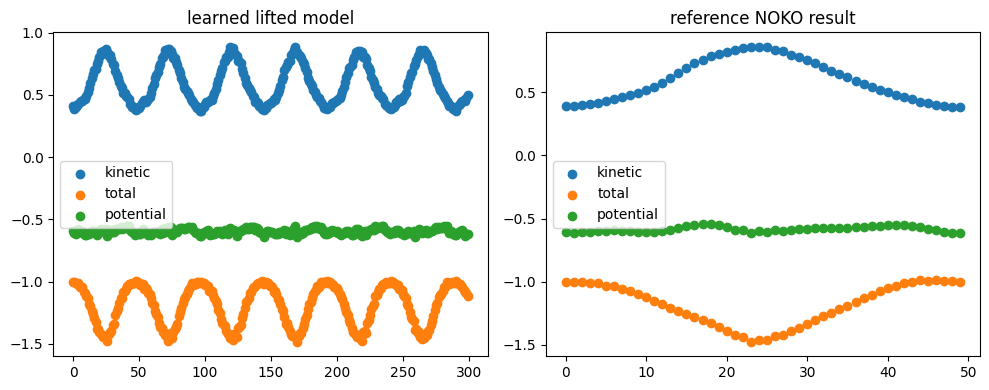

In [25]:
plt.figure(figsize=(10, 4))

plt.subplot(121)
Y = pred_y
plt.scatter(np.arange(len(k_energy(Y))), k_energy(Y), label='kinetic')
plt.scatter(np.arange(len(p_energy(Y))), p_energy(Y), label='total')
plt.scatter(np.arange(len(t_energy(Y))), t_energy(Y), label='potential')
plt.title('learned lifted model')
plt.legend()

plt.subplot(122)
try:
    Y_ref = np.load('./data/noko_0.03.npy')
    plt.scatter(np.arange(len(k_energy(Y_ref))), k_energy(Y_ref), label='kinetic')
    plt.scatter(np.arange(len(p_energy(Y_ref))), p_energy(Y_ref), label='total')
    plt.scatter(np.arange(len(t_energy(Y_ref))), t_energy(Y_ref), label='potential')
    plt.title('reference NOKO result')
    plt.legend()
except FileNotFoundError:
    plt.text(0.1, 0.5, './data/noko_0.03.npy not found')
    plt.axis('off')

plt.tight_layout()
plt.show()


## 9. Trajectory visualization

Finally, we compare the clean trajectory, the decoder reconstruction, and the long-term prediction in the position space.


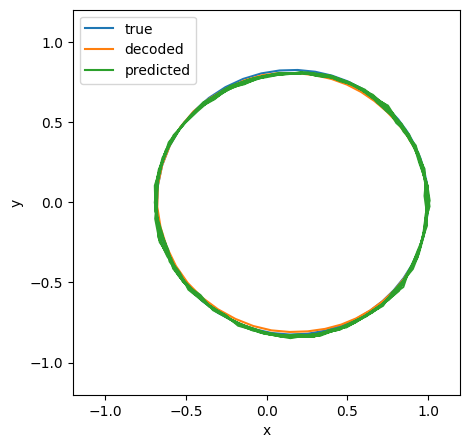

In [18]:
plt.figure(figsize=(5, 5))
plt.plot(true_y.detach().numpy()[:, 0], true_y.detach().numpy()[:, 1], label='true')
plt.plot(dec_y_np[:, 0], dec_y_np[:, 1], label='decoded')
plt.plot(pred_y[:, 0], pred_y[:, 1], label='predicted')
plt.xlim(-1.2,1.2)
plt.ylim(-1.2,1.2)
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()
